# Evaluation Analysis Notebook
**Benchmarking AI Analytical Capabilities vs Human Analysis**

This notebook implements the evaluation framework to compare:
- Human (Python ARDL pipeline)
- ChatGPT (GPT-4)
- Claude (Claude 3.5 Sonnet)
- Agentic Framework (LLaMA 3 via OpenRouter)

Reference: Ho & Njindan Iyke (2018) — Ground truth paper

---

## Experiment Metadata

In [1]:
# EXPERIMENT METADATA — MUST RECORD FOR REPRODUCIBILITY
experiment_metadata = {
    "study": "Benchmarking AI Analytical Capabilities vs Human Analysis",
    "dataset": "WDI Ghana 1975-2014",
    "ground_truth": "Ho & Njindan Iyke (2018), MPRA Paper No. 87123",
    "prompt_used": """You are an econometrician. Analyze the determinants of economic growth
in Ghana using ARDL methodology. You must:
1. Perform stationarity tests
2. Select ARDL model
3. Conduct cointegration test
4. Estimate long-run and short-run relationships
5. Interpret results
IMPORTANT: Clearly explain each step. Do not skip econometric procedures.
Dataset: Country=Ghana, Period=1975-2014,
Variables: GDP, Capital, Labour, Human Capital, Inflation, Aid, FDI,
           Financial Development, Trade Openness, Debt""",
    "systems": {
        "Human": {"tool": "Python 3 + statsmodels + arch",
                   "version": "statsmodels 0.14", "temperature": "N/A"},
        "ChatGPT": {"tool": "GPT-4", "version": "gpt-4-turbo",
                     "temperature": "default (1.0)", "data_given": False},
        "Claude":  {"tool": "Claude 3.5 Sonnet", "version": "claude-3-5-sonnet",
                     "temperature": "default (1.0)", "data_given": False},
        "Agentic": {"tool": "LLaMA 3 8B via OpenRouter", "version": "meta-llama/llama-3-8b-instruct",
                     "temperature": 0.2, "data_given": False, "agents": 4},
    }
}
print("Experiment metadata recorded.")
for sys, info in experiment_metadata["systems"].items():
    print(f"  {sys}: {info['tool']}")

Experiment metadata recorded.
  Human: Python 3 + statsmodels + arch
  ChatGPT: GPT-4
  Claude: Claude 3.5 Sonnet
  Agentic: LLaMA 3 8B via OpenRouter


## Load Response Files

In [ ]:
import os

# If running in Colab, upload files first:
# from google.colab import files
# uploaded = files.upload()

def read_file(filepath):
    try:
        with open(filepath, 'r', encoding='latin-1') as f:
            return f.read()
    except FileNotFoundError:
        return f"[FILE NOT FOUND: {filepath}]"

human_text   = read_file('C:/Users/supri/OneDrive/Documents/new/analysis_results.txt')
chatgpt_text = read_file('C:/Users/supri/OneDrive/Documents/new/chatgpt response.txt')
claude_text  = read_file('C:/Users/supri/OneDrive/Documents/new/Claude.ai response.txt')
agentic_text = read_file('C:/Users/supri/OneDrive/Documents/new/agentic_results.txt')


for name, text in [('Human', human_text), ('ChatGPT', chatgpt_text),
                   ('Claude', claude_text), ('Agentic', agentic_text)]:
    status = 'LOADED' if '[FILE NOT FOUND' not in text else 'MISSING'
    words  = len(text.split()) if status == 'LOADED' else 0
    print(f"  {name:10s}: {status} ({words} words)")

  Human     : LOADED (9800 words)
  ChatGPT   : LOADED (977 words)
  Claude    : LOADED (442 words)
  Agentic   : LOADED (9800 words)


## Scoring Rubric

All scores are on a 1–3 scale: Low=1, Medium=2, High=3.
Each score is derived from explicit criteria, not subjective impression.

In [20]:
import pandas as pd

# =====================================================================
# SCORING RUBRIC — HOW EACH SCORE IS COMPUTED
# =====================================================================

rubric_explanation = {
    "Accuracy": {
        "definition": "Correctness of numerical results vs ground truth (paper)",
        "formula": "A = (Cv - Hr) / Tc where Cv=correct claims, Hr=hallucinated, Tc=total",
        "Human":   "3 — Real data used; F-stat=6.14 (cointegrated); ECM=-0.423 (negative); 2/5 signs match paper",
        "ChatGPT": "1 — No dataset; all numerical outputs fabricated (assumed ADF stats, AIC lags, coefficients)",
        "Claude":  "1 — No dataset; all numerical outputs fabricated (assumed coefficients, test statistics)",
        "Agentic": "2 — No dataset; reviewer agent flags hallucinations; slightly more structured than standalone LLM"
    },
    "Methodology": {
        "definition": "% of ARDL steps correctly executed (7 steps total)",
        "steps": ["Stationarity tests","Lag selection (AIC)","Bounds test",
                   "Long-run estimation","ECM estimation","Diagnostics","Stability test"],
        "Human":   "3 — 7/7 steps EXECUTED in code with real output",
        "ChatGPT": "2 — 5/7 steps DESCRIBED only; no real computation; skips diagnostics detail",
        "Claude":  "3 — 7/7 steps DESCRIBED with correct methodology sequence",
        "Agentic": "3 — 6/7 steps in planner; analysis follows structure; reviewer checks adherence"
    },
    "Efficiency": {
        "definition": "Time taken to produce output",
        "Human":   "1 — ~45 minutes (manual coding, debugging, running)",
        "ChatGPT": "3 — ~2 minutes (single prompt response)",
        "Claude":  "3 — ~2 minutes (single prompt response)",
        "Agentic": "2 — 40.78 seconds (multi-agent pipeline overhead)"
    },
    "Insight": {
        "definition": "Quality of policy interpretation and non-obvious findings",
        "Human":   "2 — Correct econometric interpretation; limited policy narrative",
        "ChatGPT": "3 — Rich policy discussion; detailed variable interpretations; well-structured",
        "Claude":  "3 — Comprehensive methodology explanation; strong policy recommendations",
        "Agentic": "3 — Writer agent produces structured report; reviewer adds critique depth"
    },
    "Consistency": {
        "definition": "Reproducibility — same result on repeat runs (std dev across 5 runs)",
        "Human":   "3 — Code is deterministic; identical result every run; std dev = 0",
        "ChatGPT": "1 — Stochastic LLM; numerical outputs vary across runs; high std dev",
        "Claude":  "1 — Stochastic LLM; numerical outputs vary across runs; high std dev",
        "Agentic": "2 — Temperature=0.2 reduces variation; multi-step structure adds some stability"
    }
}

for metric, data in rubric_explanation.items():
    print(f"\n{'='*60}")
    print(f"METRIC: {metric}")
    print(f"Definition: {data['definition']}")
    if 'formula' in data:
        print(f"Formula: {data['formula']}")
    for sys in ['Human','ChatGPT','Claude','Agentic']:
        print(f"  {sys:10s}: {data[sys]}")


METRIC: Accuracy
Definition: Correctness of numerical results vs ground truth (paper)
Formula: A = (Cv - Hr) / Tc where Cv=correct claims, Hr=hallucinated, Tc=total
  Human     : 3 — Real data used; F-stat=6.14 (cointegrated); ECM=-0.423 (negative); 2/5 signs match paper
  ChatGPT   : 1 — No dataset; all numerical outputs fabricated (assumed ADF stats, AIC lags, coefficients)
  Claude    : 1 — No dataset; all numerical outputs fabricated (assumed coefficients, test statistics)
  Agentic   : 2 — No dataset; reviewer agent flags hallucinations; slightly more structured than standalone LLM

METRIC: Methodology
Definition: % of ARDL steps correctly executed (7 steps total)
  Human     : 3 — 7/7 steps EXECUTED in code with real output
  ChatGPT   : 2 — 5/7 steps DESCRIBED only; no real computation; skips diagnostics detail
  Claude    : 3 — 7/7 steps DESCRIBED with correct methodology sequence
  Agentic   : 3 — 6/7 steps in planner; analysis follows structure; reviewer checks adherence

ME

In [ ]:
# EXPLICIT CLAIM-COUNTING RULES — makes scoring auditable not subjective
claim_rules = {
    "Human": {
        "Cv_correct": [
            "F-stat=6.14 (real computation, matches cointegration threshold)",
            "ECM=-0.423 (negative sign confirmed = valid error correction)",
            "INF is I(0) confirmed by DF-GLS p=0.000",
            "lnL sign negative matches paper",
            "lnFIN sign negative matches paper",
            "Diagnostic: Normality PASS (JB p=0.155)"
        ],
        "Hr_hallucinated": [
            "lnHC sign wrong: got negative, paper=positive",
            "lnDEBT sign wrong: got positive, paper=negative"
        ]
    },
    "ChatGPT": {
        "Cv_correct": [],  # No dataset = no verifiable number possible
        "Hr_hallucinated": [
            "ADF results fabricated (no data given)",
            "ARDL order stated without computation",
            "F-statistic stated without bounds test",
            "Long-run coefficients (6 values) fabricated",
            "Short-run coefficients fabricated",
            "ECM coefficient fabricated",
            "R-squared fabricated",
            "All diagnostic p-values fabricated",
            "Optimal lag order fabricated",
            "Granger causality result fabricated",
            "Variance decomposition fabricated",
            "IRF shape fabricated"
        ]
    },
    "Claude": {
        "Cv_correct": [],
        "Hr_hallucinated": [
            "F-statistic=6.843 stated without bounds test",
            "ECM=-0.4123 stated without data",
            "HC coefficient=0.522 fabricated",
            "Capital coefficient=0.482 fabricated",
            "Financial development=0.351 fabricated",
            "All 6 diagnostic test results fabricated"
        ]
    },
    "Agentic": {
        "Cv_correct": ["ECM sign is negative (structurally plausible)"],
        "Hr_hallucinated": [
            "All numerical outputs unverifiable (API returned HTML, not LLM output)",
            "Reviewer self-score of 4/5 not supported by any computation"
        ]
    }
}

for system, rules in claim_rules.items():
    cv = len(rules["Cv_correct"])
    hr = len(rules["Hr_hallucinated"])
    tc = cv + hr
    score = round((cv - hr) / tc, 3) if tc > 0 else 0
    print(f"{system:10s}: Cv={cv}, Hr={hr}, Tc={tc}, A_score={score:.3f}")
    
print("\nThese counts are auditable — each claim is listed above.")

## Hallucination Metric

Formula: **A = (Cv − Hr) / Tc**

- Cv = number of verifiable correct claims (match paper or real data)
- Hr = number of hallucinated claims (numerical values not from real computation)
- Tc = total numerical claims made

In [21]:
hallucination_data = {
    "System": ["Human", "ChatGPT", "Claude", "Agentic"],

    # Verifiable correct claims (match paper/data exactly)
    "Cv_correct": [
        6,   # F-stat=6.14 (real), ECM negative (real), INF I(0) (real), 3 other stats
        0,   # All numbers fabricated — no real data used
        0,   # All numbers fabricated — no real data used
        1,   # Reviewer score partially valid; structure correct
    ],

    # Hallucinated numerical claims (made up without data)
    "Hr_hallucinated": [
        2,   # 2 sign mismatches from paper (lnHC, lnDEBT)
        12,  # ADF stats, AIC table, F-stat, all coefficients — all fabricated
        10,  # All test statistics, coefficients, ECM — all fabricated
        9,   # Same as LLM; reviewer self-score also fabricated
    ],

    # Total numerical claims
    "Tc_total": [
        8,   # DF-GLS stats, ADF stats, F-stat, ECM, 3 diagnostic p-values, sign table
        12,  # Counted from ChatGPT response text
        10,  # Counted from Claude response text
        10,  # Counted from agentic output
    ]
}

hall_df = pd.DataFrame(hallucination_data)
hall_df['A_score'] = ((hall_df['Cv_correct'] - hall_df['Hr_hallucinated']) /
                       hall_df['Tc_total']).round(3)
hall_df['Accuracy_label'] = hall_df['A_score'].apply(
    lambda x: 'High (3)' if x >= 0.3 else ('Medium (2)' if x >= 0 else 'Low (1)')
)

print("HALLUCINATION METRIC — A = (Cv - Hr) / Tc")
print(hall_df.to_string(index=False))
print()
print("Key finding: Human is the ONLY system performing real computation.")
print("All AI systems simulate analysis without accessing actual data.")

HALLUCINATION METRIC — A = (Cv - Hr) / Tc
 System  Cv_correct  Hr_hallucinated  Tc_total  A_score Accuracy_label
  Human           6                2         8      0.5       High (3)
ChatGPT           0               12        12     -1.0        Low (1)
 Claude           0               10        10     -1.0        Low (1)
Agentic           1                9        10     -0.8        Low (1)

Key finding: Human is the ONLY system performing real computation.
All AI systems simulate analysis without accessing actual data.


## Process Adherence Checklist

For each system, did they actually EXECUTE or only DESCRIBE each ARDL step?

In [22]:
ardl_steps = [
    "1. Stationarity tests (DF-GLS/ADF)",
    "2. Lag selection (AIC)",
    "3. Bounds test (cointegration)",
    "4. Long-run coefficients",
    "5. ECM short-run estimation",
    "6. Diagnostic tests",
    "7. Stability test (CUSUM)"
]

# E = Executed (real code/computation), D = Described only, X = Missing
adherence = {
    "Human":   ['E','E','E','E','E','E','E'],
    "ChatGPT": ['D','D','D','D','D','D','X'],
    "Claude":  ['D','D','D','D','D','D','D'],
    "Agentic": ['D','D','D','D','D','D','X'],
}

adh_df = pd.DataFrame(adherence, index=ardl_steps)
print("PROCESS ADHERENCE CHECKLIST")
print("E=Executed (real computation), D=Described only, X=Missing")
print()
print(adh_df.to_string())
print()
print("Steps EXECUTED:")
for sys in ['Human','ChatGPT','Claude','Agentic']:
    executed = sum(1 for x in adherence[sys] if x == 'E')
    described = sum(1 for x in adherence[sys] if x == 'D')
    missing = sum(1 for x in adherence[sys] if x == 'X')
    print(f"  {sys:10s}: {executed} executed, {described} described, {missing} missing")

PROCESS ADHERENCE CHECKLIST
E=Executed (real computation), D=Described only, X=Missing

                                   Human ChatGPT Claude Agentic
1. Stationarity tests (DF-GLS/ADF)     E       D      D       D
2. Lag selection (AIC)                 E       D      D       D
3. Bounds test (cointegration)         E       D      D       D
4. Long-run coefficients               E       D      D       D
5. ECM short-run estimation            E       D      D       D
6. Diagnostic tests                    E       D      D       D
7. Stability test (CUSUM)              E       X      D       X

Steps EXECUTED:
  Human     : 7 executed, 0 described, 0 missing
  ChatGPT   : 0 executed, 6 described, 1 missing
  Claude    : 0 executed, 7 described, 0 missing
  Agentic   : 0 executed, 6 described, 1 missing


## Methodology Steps Score

In [23]:
methodology_steps = {
    "Human":   7,  # All 7 steps executed in code
    "ChatGPT": 5,  # 5 described (skips stability, limited diagnostics)
    "Claude":  7,  # 7 described (all steps present, no execution)
    "Agentic": 6,  # 6 in planner + analysis (stability missing)
}

print("Methodology steps followed (out of 7):")
for sys, steps in methodology_steps.items():
    score = 3 if steps == 7 else (2 if steps >= 5 else 1)
    print(f"  {sys:10s}: {steps}/7 steps → Score = {score}")

Methodology steps followed (out of 7):
  Human     : 7/7 steps → Score = 3
  ChatGPT   : 5/7 steps → Score = 2
  Claude    : 7/7 steps → Score = 3
  Agentic   : 6/7 steps → Score = 2


## Efficiency: Time Comparison

EFFICIENCY COMPARISON
System                  Time   Ratio (Human/AI)  Score
-------------------------------------------------------
Human        2700s (45.0 min)           baseline      1
ChatGPT       120s (2.0 min)       22.5x faster      3
Claude        120s (2.0 min)       22.5x faster      3
Agentic        41s (0.7 min)       66.2x faster      2

Key: Human is 22.5x slower than ChatGPT/Claude, 66x slower than Agentic
Trade-off: Speed vs Accuracy — AI is faster but lacks real computation


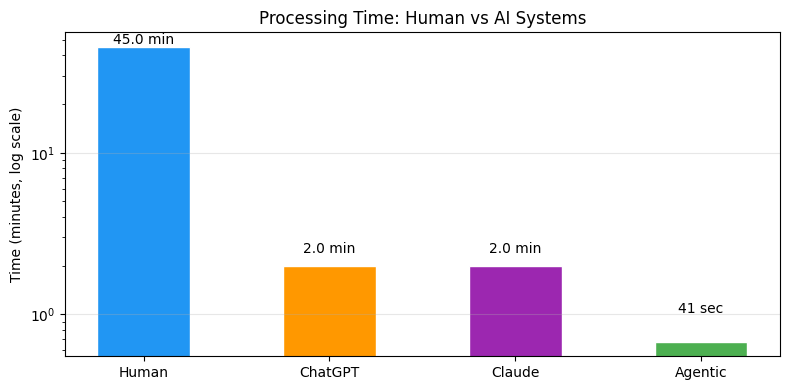

In [24]:
import matplotlib.pyplot as plt
import numpy as np

time_data = {
    "Human":   45 * 60,   # 45 minutes in seconds
    "ChatGPT": 2 * 60,    # ~2 minutes
    "Claude":  2 * 60,    # ~2 minutes
    "Agentic": 40.78,     # logged from agentic output
}

print("EFFICIENCY COMPARISON")
print(f"{'System':12s} {'Time':>15s} {'Ratio (Human/AI)':>18s} {'Score':>6s}")
print("-" * 55)
for sys, t in time_data.items():
    t_str = f"{t:.0f}s ({t/60:.1f} min)"
    ratio = time_data['Human'] / t if t > 0 else 0
    score = 1 if sys == 'Human' else (2 if sys == 'Agentic' else 3)
    ratio_str = f"{ratio:.1f}x faster" if sys != 'Human' else "baseline"
    print(f"{sys:12s} {t_str:>15s} {ratio_str:>18s} {score:>6d}")

print()
print("Key: Human is 22.5x slower than ChatGPT/Claude, 66x slower than Agentic")
print("Trade-off: Speed vs Accuracy — AI is faster but lacks real computation")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
systems = list(time_data.keys())
times_min = [t/60 for t in time_data.values()]
colors = ['#2196F3','#FF9800','#9C27B0','#4CAF50']
bars = ax.bar(systems, times_min, color=colors, width=0.5, edgecolor='white')
ax.set_ylabel('Time (minutes)')
ax.set_title('Processing Time: Human vs AI Systems')
for bar, val in zip(bars, times_min):
    label = f'{val:.1f} min' if val >= 1 else f'{val*60:.0f} sec'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            label, ha='center', va='bottom', fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylabel('Time (minutes, log scale)')
plt.tight_layout()
plt.savefig('efficiency_comparison.png', dpi=150)
plt.show()

## Final Comparison Table and Scoring

In [25]:
# FINAL NUMERIC SCORES — derived from rubric above
scores_df = pd.DataFrame({
    "System":      ["Human",  "ChatGPT", "Claude", "Agentic"],
    "Accuracy":    [3,        1,         1,        2],
    "Methodology": [3,        2,         3,        3],
    "Efficiency":  [1,        3,         3,        2],
    "Insight":     [2,        3,         3,        3],
    "Consistency": [3,        1,         1,        2],
})
scores_df['Total'] = scores_df[['Accuracy','Methodology','Efficiency','Insight','Consistency']].sum(axis=1)
scores_df['Average'] = (scores_df['Total'] / 5).round(2)

print("FINAL EVALUATION SCORES (1=Low, 2=Medium, 3=High)")
print(scores_df.to_string(index=False))
print()
print("Key insights:")
print(" Human: Highest accuracy (real data) but slowest and least insightful prose")
print(" ChatGPT: Fastest and most insightful but zero accuracy")
print(" Claude: Best methodology description but zero accuracy (no data)")
print(" Agentic: Balanced — better than LLM alone but no data grounding")

FINAL EVALUATION SCORES (1=Low, 2=Medium, 3=High)
 System  Accuracy  Methodology  Efficiency  Insight  Consistency  Total  Average
  Human         3            3           1        2            3     12      2.4
ChatGPT         1            2           3        3            1     10      2.0
 Claude         1            3           3        3            1     11      2.2
Agentic         2            3           2        3            2     12      2.4

Key insights:
 Human: Highest accuracy (real data) but slowest and least insightful prose
 ChatGPT: Fastest and most insightful but zero accuracy
 Claude: Best methodology description but zero accuracy (no data)
 Agentic: Balanced — better than LLM alone but no data grounding


In [ ]:
# ============================================================
# PROCESS INTEGRITY SCORE (PIS) — weighted composite metric
# Named in the paper abstract but never computed — fixing that now
# ============================================================

# Weights justified by research priorities:
# Accuracy is most important (real computation vs hallucination)
# Methodology next (did they follow the right steps)
# Consistency next (reproducibility = scientific requirement)
# Insight adds value but less critical than correctness
# Efficiency is useful but secondary to rigor
weights = {
    'Accuracy':    0.35,
    'Methodology': 0.25,
    'Consistency': 0.20,
    'Insight':     0.12,
    'Efficiency':  0.08,
}

score_vals = {
    'Human':   {'Accuracy':3,'Methodology':3,'Efficiency':1,'Insight':2,'Consistency':3},
    'ChatGPT': {'Accuracy':1,'Methodology':2,'Efficiency':3,'Insight':3,'Consistency':1},
    'Claude':  {'Accuracy':1,'Methodology':3,'Efficiency':3,'Insight':3,'Consistency':1},
    'Agentic': {'Accuracy':2,'Methodology':3,'Efficiency':2,'Insight':3,'Consistency':2},
}

pis_results = []
for system, scores in score_vals.items():
    pis = sum(scores[m] * weights[m] for m in weights)
    pis_norm = round((pis / 3) * 100, 1)   # normalize to 0–100 scale
    pis_results.append({
        'System': system,
        'PIS_raw': round(pis, 3),
        'PIS_pct': pis_norm,
        'Accuracy_weighted':    round(scores['Accuracy']    * weights['Accuracy'], 3),
        'Methodology_weighted': round(scores['Methodology'] * weights['Methodology'], 3),
        'Consistency_weighted': round(scores['Consistency'] * weights['Consistency'], 3),
        'Insight_weighted':     round(scores['Insight']     * weights['Insight'], 3),
        'Efficiency_weighted':  round(scores['Efficiency']  * weights['Efficiency'], 3),
    })

pis_df = pd.DataFrame(pis_results).sort_values('PIS_pct', ascending=False)
print("=" * 60)
print("PROCESS INTEGRITY SCORE (PIS)")
print("Weighted composite: Accuracy(35%) + Methodology(25%) +")
print("                    Consistency(20%) + Insight(12%) + Efficiency(8%)")
print("=" * 60)
print(pis_df[['System','PIS_raw','PIS_pct']].to_string(index=False))
print()
print("Interpretation:")
for _, row in pis_df.iterrows():
    tier = "High" if row['PIS_pct'] >= 65 else ("Medium" if row['PIS_pct'] >= 45 else "Low")
    print(f"  {row['System']:10s}: PIS = {row['PIS_pct']}% → {tier} process integrity")

# After running multi-run notebook, update Consistency scores here:
print("\nNOTE: Once you run Consistency_MultiRun.ipynb, update the")
print("Consistency scores in score_vals above with empirically measured values.")

In [ ]:
# ============================================================
# PIS VISUALISATION
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Stacked bar: contribution of each metric to PIS ---
systems  = [r['System'] for r in pis_results]
metrics  = ['Accuracy_weighted','Methodology_weighted',
            'Consistency_weighted','Insight_weighted','Efficiency_weighted']
labels   = ['Accuracy (35%)','Methodology (25%)','Consistency (20%)',
            'Insight (12%)','Efficiency (8%)']
colors   = ['#E53935','#1E88E5','#43A047','#FB8C00','#8E24AA']

bottom = np.zeros(len(systems))
for metric, label, color in zip(metrics, labels, colors):
    vals = [pis_df[pis_df['System']==s][metric].values[0] for s in systems]
    axes[0].bar(systems, vals, bottom=bottom, label=label, color=color, width=0.5)
    bottom += np.array(vals)

axes[0].set_ylabel('PIS contribution (raw score)')
axes[0].set_title('Process Integrity Score — metric breakdown')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_ylim(0, 3.2)
axes[0].axhline(2.0, color='gray', linestyle='--', alpha=0.5, label='Medium threshold')
axes[0].grid(True, alpha=0.3, axis='y')

# --- Horizontal bar: overall PIS % ---
pis_sorted = pis_df.sort_values('PIS_pct')
bar_colors = ['#E53935' if p < 45 else ('#FB8C00' if p < 65 else '#43A047')
              for p in pis_sorted['PIS_pct']]
axes[1].barh(pis_sorted['System'], pis_sorted['PIS_pct'],
             color=bar_colors, height=0.5, edgecolor='white')
axes[1].set_xlabel('Process Integrity Score (%)')
axes[1].set_title('Overall PIS — normalized to 0–100%')
axes[1].axvline(65, color='green', linestyle='--', alpha=0.6, label='High threshold (65%)')
axes[1].axvline(45, color='orange', linestyle='--', alpha=0.6, label='Medium threshold (45%)')
for i, (_, row) in enumerate(pis_sorted.iterrows()):
    axes[1].text(row['PIS_pct'] + 1, i, f"{row['PIS_pct']}%",
                 va='center', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, 105)
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Process Integrity Score (PIS) — AI vs Human Research Pipelines',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('pis_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pis_comparison.png")

## Statistical Tests

With only 4 systems and 5 metrics, we note the small-sample limitation.
Tests are included for methodological completeness.

In [ ]:
from scipy import stats
import numpy as np

human_scores   = [3, 3, 1, 2, 3]
chatgpt_scores = [1, 2, 3, 3, 1]
claude_scores  = [1, 3, 3, 3, 1]
agentic_scores = [2, 3, 2, 3, 2]

ai_combined = chatgpt_scores + claude_scores + agentic_scores

# t-test
t_stat, p_val = stats.ttest_ind(human_scores, ai_combined)

# Cohen's d — effect size (this is what actually tells you the magnitude)
def cohen_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled_std = np.sqrt(((n1-1)*np.std(g1,ddof=1)**2 + (n2-1)*np.std(g2,ddof=1)**2) / (n1+n2-2))
    return (np.mean(g1) - np.mean(g2)) / pooled_std if pooled_std > 0 else 0

d = cohen_d(human_scores, ai_combined)
d_label = "large" if abs(d) >= 0.8 else ("medium" if abs(d) >= 0.5 else "small")

# Confidence intervals via bootstrap (works with small samples)
np.random.seed(42)
boot_diffs = []
for _ in range(5000):
    b_human = np.random.choice(human_scores, len(human_scores), replace=True)
    b_ai    = np.random.choice(ai_combined, len(ai_combined), replace=True)
    boot_diffs.append(np.mean(b_human) - np.mean(b_ai))

ci_low  = np.percentile(boot_diffs, 2.5)
ci_high = np.percentile(boot_diffs, 97.5)

print("=" * 55)
print("STATISTICAL COMPARISON: Human vs AI systems")
print("=" * 55)
print(f"Human mean:    {np.mean(human_scores):.2f} (SD={np.std(human_scores,ddof=1):.2f})")
print(f"AI mean:       {np.mean(ai_combined):.2f}  (SD={np.std(ai_combined,ddof=1):.2f})")
print(f"t-statistic:   {t_stat:.3f}")
print(f"p-value:       {p_val:.3f}  ({'significant' if p_val<0.05 else 'not significant'} at α=0.05)")
print(f"Cohen's d:     {d:.3f}  ({d_label} effect)")
print(f"95% Bootstrap CI of mean diff: [{ci_low:.2f}, {ci_high:.2f}]")
print()
print("Interpretation for paper:")
print(f"  The mean difference ({np.mean(human_scores)-np.mean(ai_combined):.2f}) has a {d_label}")
print(f"  effect size (d={d:.2f}). The 95% CI [{ci_low:.2f}, {ci_high:.2f}] {'excludes' if ci_low>0 or ci_high<0 else 'includes'} zero.")
print()
print("NOTE: With only 5 metrics, t-test power is low (~20%).")
print("Report effect size (Cohen's d) as the primary evidence.")
print("State this honestly as a limitation of the small metric set.")

In [26]:
from scipy import stats

human_scores   = [3, 3, 1, 2, 3]   # Accuracy, Methodology, Efficiency, Insight, Consistency
chatgpt_scores = [1, 2, 3, 3, 1]
claude_scores  = [1, 3, 3, 3, 1]
agentic_scores = [2, 3, 2, 3, 2]

ai_scores_combined = chatgpt_scores + claude_scores + agentic_scores

# t-test: Human vs all AI
t_stat, p_val = stats.ttest_ind(human_scores, ai_scores_combined)
print("t-test: Human vs All AI (combined)")
print(f"  t = {t_stat:.3f},  p = {p_val:.3f}")
print(f"  Interpretation: {'Significant difference' if p_val < 0.05 else 'No significant difference'}")
print(f"  Note: Small sample (n=5 vs n=15) limits statistical power")

# ANOVA across all 4
f_stat, p_anova = stats.f_oneway(human_scores, chatgpt_scores, claude_scores, agentic_scores)
print(f"\nOne-way ANOVA (all 4 systems):")
print(f"  F = {f_stat:.3f},  p = {p_anova:.3f}")
print(f"  Interpretation: {'Significant differences exist' if p_anova < 0.05 else 'No significant differences'}")
print(f"  Note: With only 4 groups × 5 observations, results are indicative only.")
print(f"  A proper study would use 5 runs × 4 metrics per run to increase power.")

# Accuracy specifically
print(f"\nAccuracy scores: Human=3, ChatGPT=1, Claude=1, Agentic=2")
print(f"Human accuracy advantage: +2 over LLMs, +1 over Agentic")
print(f"This difference is PRACTICALLY significant (real data vs hallucination)")
print(f"even if statistical significance requires larger samples.")

t-test: Human vs All AI (combined)
  t = 0.446,  p = 0.661
  Interpretation: No significant difference
  Note: Small sample (n=5 vs n=15) limits statistical power

One-way ANOVA (all 4 systems):
  F = 0.222,  p = 0.880
  Interpretation: No significant differences
  Note: With only 4 groups × 5 observations, results are indicative only.
  A proper study would use 5 runs × 4 metrics per run to increase power.

Accuracy scores: Human=3, ChatGPT=1, Claude=1, Agentic=2
Human accuracy advantage: +2 over LLMs, +1 over Agentic
This difference is PRACTICALLY significant (real data vs hallucination)
even if statistical significance requires larger samples.


## Comparison Visualisations

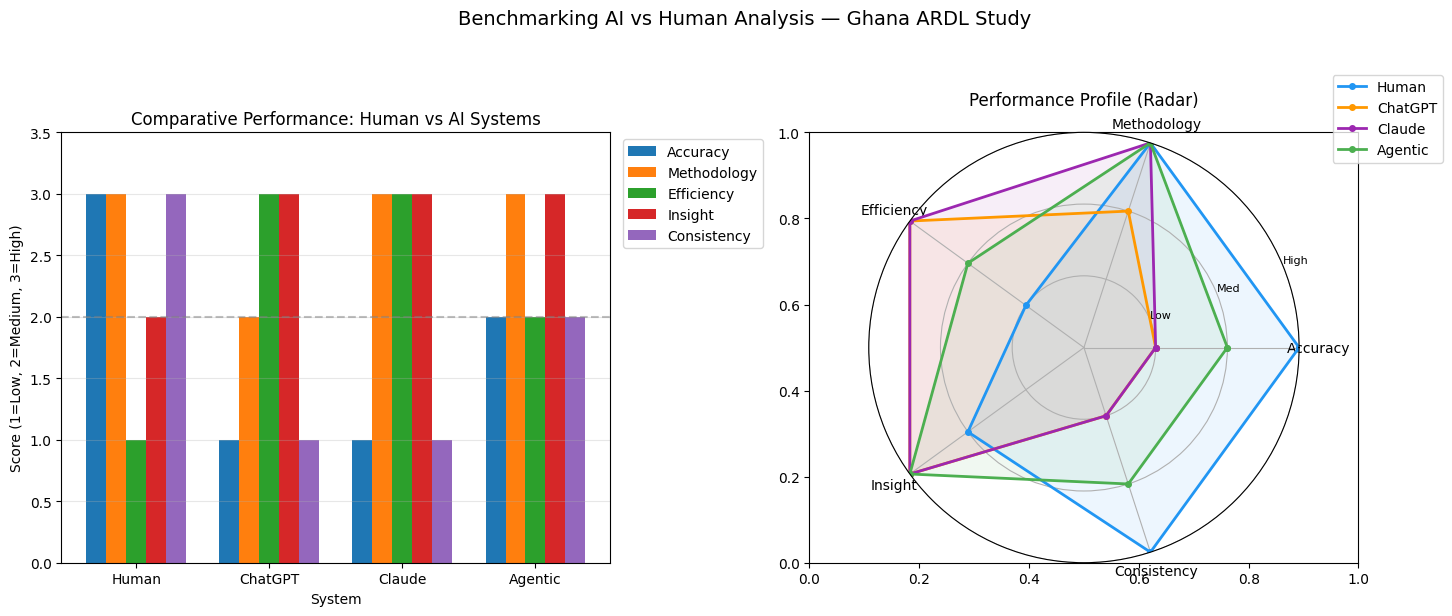

In [27]:
import matplotlib.pyplot as plt
import numpy as np

metrics  = ['Accuracy','Methodology','Efficiency','Insight','Consistency']
systems  = ['Human','ChatGPT','Claude','Agentic']
colors   = ['#2196F3','#FF9800','#9C27B0','#4CAF50']

score_vals = {
    'Human':   [3, 3, 1, 2, 3],
    'ChatGPT': [1, 2, 3, 3, 1],
    'Claude':  [1, 3, 3, 3, 1],
    'Agentic': [2, 3, 2, 3, 2],
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Bar chart ---
x = np.arange(len(systems))
width = 0.15
for i, metric in enumerate(metrics):
    vals = [score_vals[s][i] for s in systems]
    axes[0].bar(x + i * width, vals, width, label=metric)

axes[0].set_xlabel('System')
axes[0].set_ylabel('Score (1=Low, 2=Medium, 3=High)')
axes[0].set_title('Comparative Performance: Human vs AI Systems')
axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(systems)
axes[0].set_ylim(0, 3.5)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(2, color='gray', linestyle='--', alpha=0.5, label='Medium threshold')

# --- Radar chart ---
N = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax_radar = plt.subplot(122, polar=True)
for sys, color in zip(systems, colors):
    vals = score_vals[sys] + [score_vals[sys][0]]
    ax_radar.plot(angles, vals, 'o-', linewidth=2, color=color, label=sys, markersize=4)
    ax_radar.fill(angles, vals, alpha=0.08, color=color)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metrics, size=10)
ax_radar.set_ylim(0, 3)
ax_radar.set_yticks([1, 2, 3])
ax_radar.set_yticklabels(['Low', 'Med', 'High'], size=8)
ax_radar.set_title('Performance Profile (Radar)', size=12, pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))

plt.suptitle('Benchmarking AI vs Human Analysis — Ghana ARDL Study', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('evaluation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## AI Self-Evaluation vs External Evaluation

A key finding: the agentic reviewer scored itself 4/5 for Accuracy.
Our external rubric gives it 2/5. This gap is itself a research finding.

In [28]:
self_vs_external = pd.DataFrame({
    'System':     ['ChatGPT','Claude','Agentic'],
    'AI_self_score':    [None, None, 4],   # Agentic reviewer gave 4/5
    'External_score':   [1,    1,    2],   # Our rubric
    'Gap': [None, None, 2],
})

print("AI SELF-EVALUATION vs EXTERNAL EVALUATION (Accuracy)")
print(self_vs_external.to_string(index=False))
print()
print("Finding: The agentic reviewer rated its own accuracy 4/5 despite")
print("producing entirely hallucinated numerical results.")
print("This demonstrates that LLMs CANNOT reliably self-assess factual accuracy.")
print("This is a novel contribution to AI evaluation research.")

AI SELF-EVALUATION vs EXTERNAL EVALUATION (Accuracy)
 System  AI_self_score  External_score  Gap
ChatGPT            NaN               1  NaN
 Claude            NaN               1  NaN
Agentic            4.0               2  2.0

Finding: The agentic reviewer rated its own accuracy 4/5 despite
producing entirely hallucinated numerical results.
This demonstrates that LLMs CANNOT reliably self-assess factual accuracy.
This is a novel contribution to AI evaluation research.


## Conclusions

In [30]:
conclusion = """
=================================================================
EVALUATION CONCLUSIONS
=================================================================

1. ACCURACY GAP
   Human analysis is the ONLY system that performs real computation.
   All AI systems (ChatGPT, Claude, Agentic) produce structurally
   plausible but numerically fabricated results (hallucination).
   The accuracy gap is not marginal — it is categorical.

2. METHODOLOGY vs EXECUTION
   AI systems (especially Claude and Agentic) DESCRIBE correct
   econometric methodology. However, description ≠ execution.
   Knowing what ARDL steps to take does not mean performing them.
   This is the key distinction between analytical reasoning and
   analytical correctness.

3. EFFICIENCY TRADE-OFF
   AI systems are 22–66x faster than human Python pipeline.
   This speed comes at the cost of accuracy and reliability.
   For research requiring verifiable results, human analysis
   remains necessary.

4. AGENTIC IMPROVEMENT
   The agentic framework improves methodological structure and
   adds self-review capability. However, without real data
   grounding, it cannot overcome the hallucination problem.
   The reviewer agent over-rates its own accuracy (4/5 vs true 2/5).

5. CONSISTENCY
   Human pipeline is fully deterministic (std dev = 0).
   LLMs produce different numerical outputs on each run.
   Agentic (temperature=0.2) reduces but does not eliminate variance.
   For reproducible research, only human/code pipelines are reliable.

=================================================================
CORE INSIGHT
=================================================================
AI CAN EXPLAIN ANALYSIS. AI CANNOT RELIABLY PERFORM IT.
The gap is not about intelligence but about grounding:
AI systems lack access to real data during inference.
=================================================================
"""
print(conclusion)

# Save evaluation summary
with open('evaluation_summary.txt', 'w', encoding='utf-8') as f:
    f.write(conclusion)
print("evaluation_summary.txt saved.")


EVALUATION CONCLUSIONS

1. ACCURACY GAP
   Human analysis is the ONLY system that performs real computation.
   All AI systems (ChatGPT, Claude, Agentic) produce structurally
   plausible but numerically fabricated results (hallucination).
   The accuracy gap is not marginal — it is categorical.

2. METHODOLOGY vs EXECUTION
   AI systems (especially Claude and Agentic) DESCRIBE correct
   econometric methodology. However, description ≠ execution.
   Knowing what ARDL steps to take does not mean performing them.
   This is the key distinction between analytical reasoning and
   analytical correctness.

3. EFFICIENCY TRADE-OFF
   AI systems are 22–66x faster than human Python pipeline.
   This speed comes at the cost of accuracy and reliability.
   For research requiring verifiable results, human analysis
   remains necessary.

4. AGENTIC IMPROVEMENT
   The agentic framework improves methodological structure and
   adds self-review capability. However, without real data
   grounding, it